# Modèle 3 — XGBoost (Gradient Boosting)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, mean_absolute_error,
    mean_squared_error, r2_score
)

RANDOM_STATE = 42
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print("Imports OK")

Imports OK


## Chargement des données preprocessées

Mêmes données que les modèles précédents.
On charge les fichiers .npy générés par le preprocessing.

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

# Classification — données rééquilibrées par undersampling
X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# SMOTE
X_train_smote     = np.load('../data/processed/X_train_smote.npy')
y_train_clf_smote = np.load('../data/processed/y_train_clf_smote.npy')

# Labels originaux (pour régression)
y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

print(f"Données chargées")
print(f"   X_train         : {X_train.shape} (original)")
print(f"   X_train_under   : {X_train_under.shape} (rééquilibré 50/50)")
print(f"   X_test          : {X_test.shape}")
print(f"   Churners train_under : {y_train_clf_under.sum()} ({y_train_clf_under.mean()*100:.1f}%)")
print(f"   Churners test        : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")


Données chargées
   X_train         : (8000, 50) (original)
   X_train_under   : (1634, 50) (rééquilibré 50/50)
   X_test          : (2000, 50)
   Churners train_under : 817 (50.0%)
   Churners test        : 204 (10.2%)


## Tâche 1 — Classification du Churn


In [3]:
# TÂCHE 1 — CLASSIFICATION

# ---- Modèle 1 : Undersampling ----
# TÂCHE 1 — CLASSIFICATION

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,  # Données déjà équilibrées par undersampling
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    verbosity=0
)
X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# Entraînement sur les données rééquilibrées (undersampling)
xgb_clf.fit(X_train_under, y_train_clf_under)

y_pred_under  = xgb_clf.predict(X_test)
y_proba_under = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_clf    = y_pred_under
y_proba_clf = xgb_clf.predict_proba(X_test)[:, 1]

print(" Modèle entraîné !")
print(f"\n Résultats — XGBoost (Classification)")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_clf):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_clf):.4f}")

print()

# ---- Modèle 2 : SMOTE ----
xgb_clf_smote = xgb_clf.__class__(**xgb_clf.get_params())
xgb_clf_smote.fit(X_train_smote, y_train_clf_smote)
y_pred_smote  = xgb_clf_smote.predict(X_test)
y_proba_smote = xgb_clf_smote.predict_proba(X_test)[:, 1]

print(f"=== XGBoost — SMOTE ===")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_smote):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_smote):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_smote):.4f}")

# Sélection du meilleur
f1_under = recall_score(y_test_clf, y_pred_clf)
f1_smote = recall_score(y_test_clf, y_pred_smote)
if f1_smote >= f1_under:
    xgb_clf = xgb_clf_smote
    y_pred_clf  = y_pred_smote
    y_proba_clf = y_proba_smote
    best_technique = 'SMOTE'
else:
    best_technique = 'Undersampling'
print(f"\n→ Meilleure technique : {best_technique} (Recall={max(f1_under, f1_smote):.4f})")

 Modèle entraîné !

 Résultats — XGBoost (Classification)
   Accuracy  : 0.7190
   Precision : 0.2383
   Recall    : 0.7990
   F1-Score  : 0.3671
   ROC-AUC   : 0.7837

=== XGBoost — SMOTE ===
   Accuracy  : 0.8890
   Precision : 0.2632
   Recall    : 0.0490
   F1-Score  : 0.0826
   ROC-AUC   : 0.7718

→ Meilleure technique : Undersampling (Recall=0.7990)


## 🔴 Matrice de Confusion


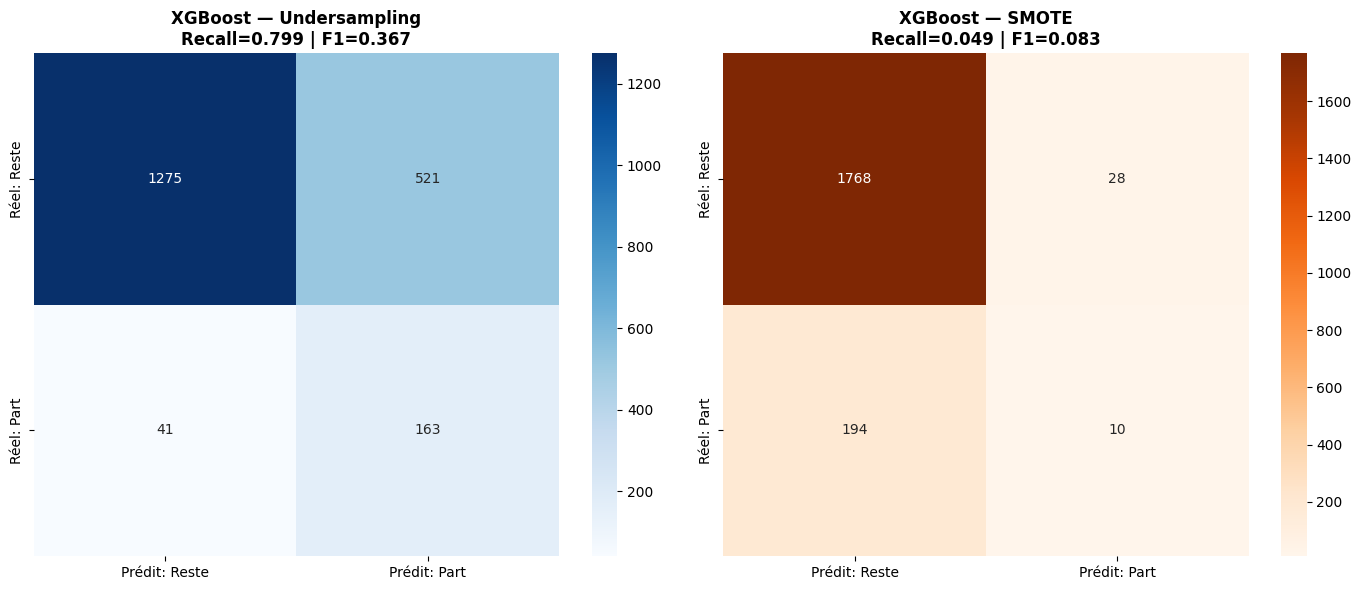


Meilleur modèle (Undersampling) :
   FN (churners manqués) : 41
   TP (churners détectés) : 163


In [4]:
# MATRICE DE CONFUSION — Comparaison

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (y_pred, title, cmap) in zip(axes, [
    (y_pred_under, 'XGBoost — Undersampling', 'Blues'),
    (y_pred_smote, 'XGBoost — SMOTE', 'Oranges'),
]):
    cm_plot = confusion_matrix(y_test_clf, y_pred)
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Prédit: Reste', 'Prédit: Part'],
                yticklabels=['Réel: Reste', 'Réel: Part'], ax=ax)
    ax.set_title(f'{title}\nRecall={recall_score(y_test_clf, y_pred):.3f} | F1={f1_score(y_test_clf, y_pred):.3f}',
                 fontweight='bold')

plt.tight_layout()
plt.savefig('../results/xgb_confusion_matrix.png', dpi=150)
plt.show()

cm = confusion_matrix(y_test_clf, y_pred_clf)
tn, fp, fn, tp = cm.ravel()
print(f"\nMeilleur modèle ({best_technique}) :")
print(f"   FN (churners manqués) : {fn}")
print(f"   TP (churners détectés) : {tp}")

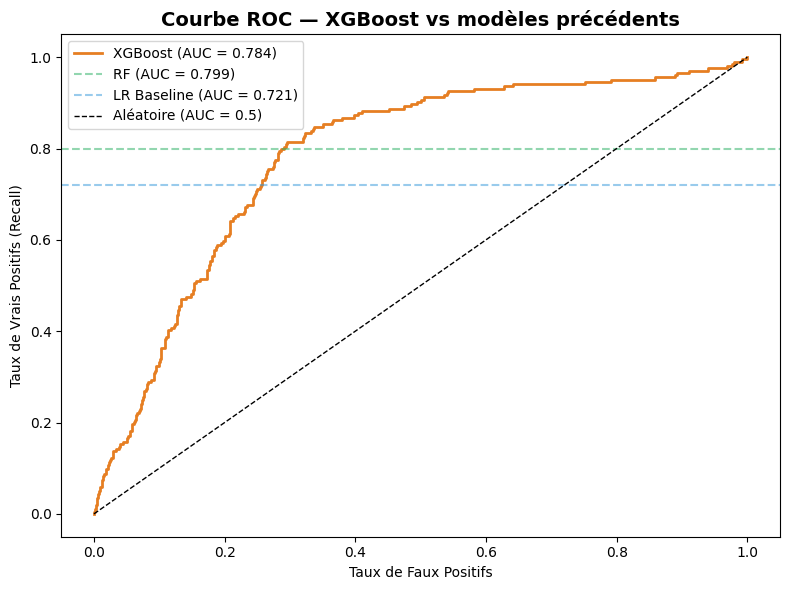

In [5]:
# COURBE ROC — Comparaison tous les modèles

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
auc = roc_auc_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e67e22', linewidth=2,
         label=f'XGBoost (AUC = {auc:.3f})')
plt.axhline(y=0.7993, color='#27ae60', linestyle='--',
            alpha=0.5, label='RF (AUC = 0.799)')
plt.axhline(y=0.7212, color='#3498db', linestyle='--',
            alpha=0.5, label='LR Baseline (AUC = 0.721)')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC — XGBoost vs modèles précédents',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/xgb_roc_curve.png', dpi=150)
plt.show()

## 🔍 Feature Importance XGBoost


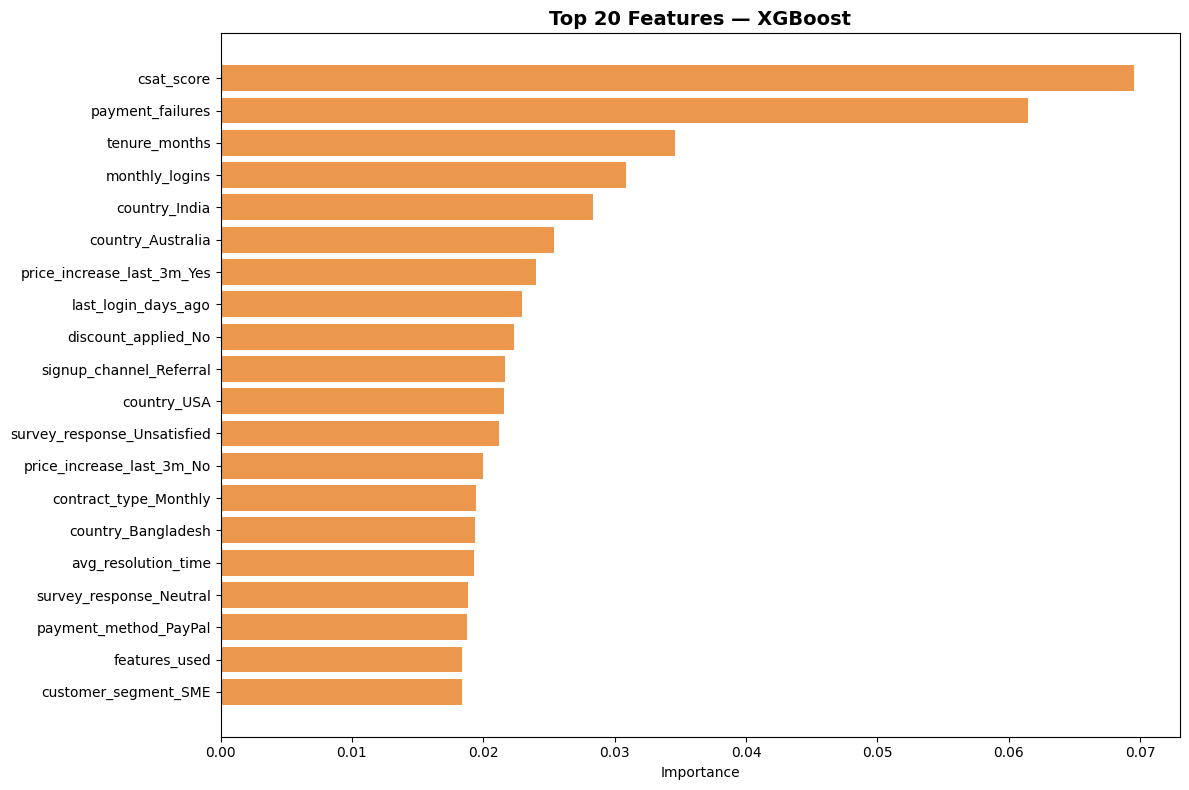


 Top 10 features les plus importantes :
   1. csat_score                          : 0.0696
   2. payment_failures                    : 0.0615
   3. tenure_months                       : 0.0346
   4. monthly_logins                      : 0.0308
   5. country_India                       : 0.0283
   6. country_Australia                   : 0.0254
   7. price_increase_last_3m_Yes          : 0.0240
   8. last_login_days_ago                 : 0.0229
   9. discount_applied_No                 : 0.0224
   10. signup_channel_Referral             : 0.0216


In [6]:
# FEATURE IMPORTANCE

importances = xgb_clf.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 8))
plt.barh(range(20),
         importances[indices][::-1],
         color='#e67e22', alpha=0.8)
plt.yticks(range(20),
           [feature_names[i] for i in indices][::-1],
           fontsize=10)
plt.xlabel('Importance')
plt.title('Top 20 Features — XGBoost',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/xgb_feature_importance.png', dpi=150)
plt.show()

print("\n Top 10 features les plus importantes :")
for i in range(10):
    print(f"   {i+1}. {feature_names[indices[i]]:35} : {importances[indices[i]]:.4f}")

## Tâche 2 — Régression du Revenu à Risque


In [7]:
# TÂCHE 2 — RÉGRESSION XGBoost

X_train_reg     = np.load('../data/processed/X_train_reg.npy')
y_train_reg_log = np.load('../data/processed/y_train_reg_log.npy')
y_test_reg      = np.load('../data/processed/y_test_reg.npy')

xgb_reg = XGBRegressor(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.5,
    min_child_weight=20,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb_reg.fit(X_train_reg, y_train_reg_log)

y_pred_reg_log = xgb_reg.predict(X_test)
y_pred_reg = np.expm1(y_pred_reg_log)
y_pred_reg = np.maximum(y_pred_reg, 0)

churners_test_mask = y_test_reg > 0
mae  = mean_absolute_error(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask])
rmse = np.sqrt(mean_squared_error(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask]))
r2   = r2_score(y_test_reg[churners_test_mask], y_pred_reg[churners_test_mask])

print("Modèle de régression entraîné !")
print(f"\nRésultats — XGBoost Regression (churners uniquement)")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")

Modèle de régression entraîné !

Résultats — XGBoost Regression (churners uniquement)
   MAE  : 166.09 €
   RMSE : 370.00 €
   R²   : 0.8485


In [8]:
# SAUVEGARDE

print(f'Sauvegarde du meilleur modèle : {best_technique}')
joblib.dump(xgb_clf, '../models/xgb_classification.pkl')
joblib.dump(xgb_reg, '../models/xgb_regression.pkl')

results_clf = {
    'model'    : 'XGBoost',
    'accuracy' : accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall'   : recall_score(y_test_clf, y_pred_clf),
    'f1'       : f1_score(y_test_clf, y_pred_clf),
    'roc_auc'  : roc_auc_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'XGBoost Regression',
    'mae' : mae,
    'rmse': rmse,
    'r2'  : r2
}

pd.DataFrame([results_clf]).to_csv('../results/xgb_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/xgb_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("Résultats sauvegardés dans ../results/")
print(f"\n Résumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Sauvegarde du meilleur modèle : Undersampling
Modèles sauvegardés dans ../models/
Résultats sauvegardés dans ../results/

 Résumé Classification :
   accuracy   : 0.7190
   precision  : 0.2383
   recall     : 0.7990
   f1         : 0.3671
   roc_auc    : 0.7837


## Synthèse — XGBoost
